# Second-Order Autoregressive Dynamics in the Complex Plane

AR(2) processes are the simplest linear recurrences with oscillatory behavior and memory:
$$
X_{t+1}=aX_t+bX_{t-1}+W_t.
$$
Stability and covariance structure are encoded by roots of the characteristic polynomial.

We simulate complex AR(2) trajectories, inspect long-run clouds, and estimate autocorrelation decay.

For an AR(2) recurrence, the roots of the characteristic polynomial determine everything: decay, oscillation frequency, and stability. Writing $z_{n+2}=a z_{n+1}+b z_n$ turns the dynamics into a two-dimensional linear map; the visualizations connect its eigenvalues to trajectories and correlation decay.


## Environment

Complex-valued simulation allows us to visualize trajectories as 2D curves.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(4)


## Stable parameterization

Choose radius $r<1$ and angle $\theta$, with characteristic roots $re^{\pm i\theta}$.

With roots $re^{\pm i\theta}$, the AR(2) coefficients are $a = 2r\cos\theta$ and $b = -r^2$.  The process is stable for $r < 1$, with oscillation period $T = 2\pi/\theta$ and damping timescale $\sim 1/(1-r)$.


In [2]:
def params_from_polar(r=0.95, theta=0.15):
    # Characteristic polynomial: z^2 - a z - b = 0
    # Roots r*exp(+/-i theta) => a=2r cos(theta), b=-r^2
    a = 2 * r * np.cos(theta)
    b = -(r**2)
    return a, b

a, b = params_from_polar(0.88, 0.18)
print("a=", a, "b=", b)


a= 1.7315648993070938 b= -0.7744


## AR(2) simulation

Generate $p$ independent trajectories after a warm-up phase to approximate stationarity.  Using $n = 2000$ steps is sufficient to see clear oscillatory patterns without trajectories spiraling into a clump.


In [3]:
def simulate_ar2(a, b, n=2000, warmup=300, p=12, noise_scale=1.0):
    total = n + warmup
    x = np.zeros((total + 2, p), dtype=np.complex128)
    for t in range(2, total + 2):
        w = noise_scale * (rng.standard_normal(p) + 1j * rng.standard_normal(p))
        x[t] = a * x[t - 1] + b * x[t - 2] + w
    return x[warmup + 2:]

X = simulate_ar2(a, b, n=2000, warmup=300, p=12, noise_scale=0.8)


## Representative trajectories

Each particle is one realization of the same AR(2) law.  Plotting only the **first 300 time steps** exposes the spiral geometry before noise accumulation washes out the pattern.


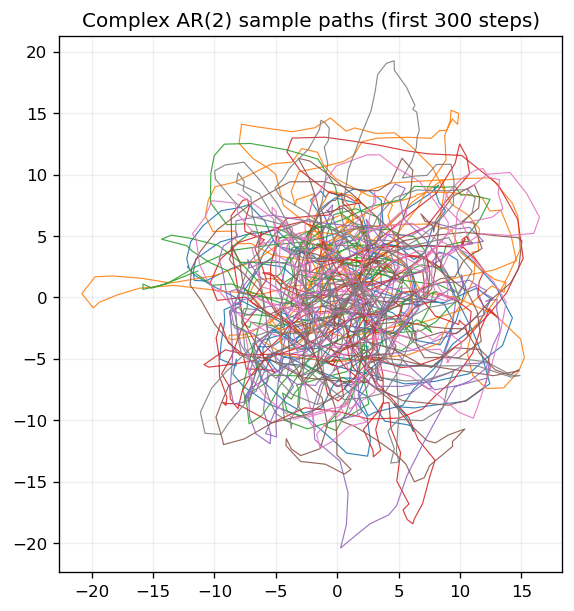

In [4]:
fig, ax = plt.subplots(figsize=(5.8, 5.8))
for j in range(min(8, X.shape[1])):
    z = X[:300, j]   # first 300 time steps — clear spirals, no clumping
    ax.plot(z.real, z.imag, lw=0.7, alpha=0.9)
ax.set_aspect("equal")
ax.set_title("Complex AR(2) sample paths (first 300 steps)")
ax.grid(alpha=0.2)
plt.show()
fig.savefig("snippet.png", bbox_inches="tight")
plt.close(fig)


## Empirical autocorrelation

Estimate $\gamma(k)=\mathbb E[X_t\overline{X_{t-k}}]$ from one long realization.  A dedicated longer run ($n=3000$) is used here to reduce variance in the estimate.


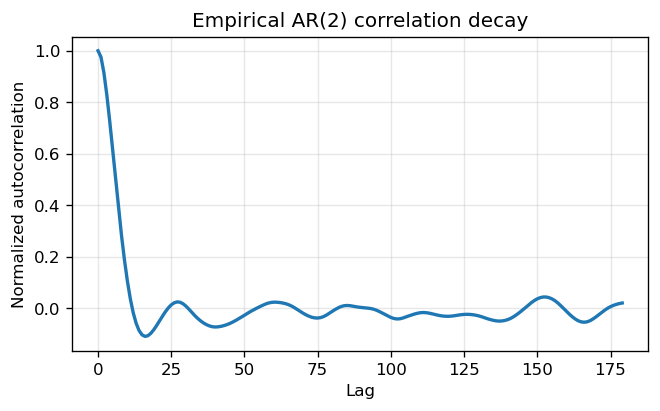

In [5]:
# Use a longer dedicated simulation for stable autocorrelation estimation
a_ac, b_ac = params_from_polar(0.88, 0.18)
X_long = simulate_ar2(a_ac, b_ac, n=3000, warmup=500, p=1, noise_scale=0.8)
z = X_long[:, 0] - X_long[:, 0].mean()
K = 180
ac = np.array([np.mean(z[k:] * np.conj(z[:-k])) if k > 0 else np.mean(z * np.conj(z)) for k in range(K)])
acn = np.real(ac / ac[0])

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(acn, lw=2)
ax.set_xlabel("Lag")
ax.set_ylabel("Normalized autocorrelation")
ax.set_title("Empirical AR(2) correlation decay")
ax.grid(alpha=0.3)
plt.show()
fig.savefig("autocorr.png", bbox_inches="tight")
plt.close(fig)


## Interactive stability exploration

Vary $r$ and phase $\theta$ to observe transition from rapid damping to persistent oscillation.  The left panel shows the real and imaginary time series; the right shows the phase portrait in $\mathbb{C}$.


interactive(children=(FloatSlider(value=0.88, description='r', max=0.99, min=0.5, step=0.01), FloatSlider(valu…

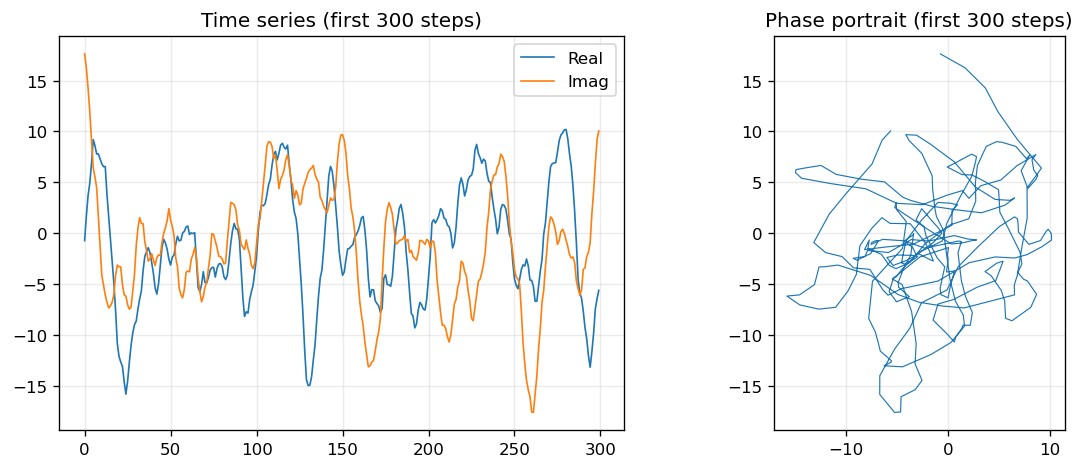

In [6]:
def preview_ar2(r=0.88, theta=0.18, n=1500):
    a, b = params_from_polar(r, theta)
    X = simulate_ar2(a, b, n=n, warmup=300, p=1, noise_scale=0.9).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
    axes[0].plot(X.real[:300], lw=1.0, label="Real")
    axes[0].plot(X.imag[:300], lw=1.0, label="Imag")
    axes[0].set_title("Time series (first 300 steps)")
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    axes[1].plot(X.real[:300], X.imag[:300], lw=0.7)
    axes[1].set_aspect("equal")
    axes[1].set_title("Phase portrait (first 300 steps)")
    axes[1].grid(alpha=0.25)
    plt.show()

interact(preview_ar2,
         r=FloatSlider(min=0.5, max=0.99, step=0.01, value=0.88, description="r"),
         theta=FloatSlider(min=0.05, max=1.0, step=0.01, value=0.18, description="theta"));

# Static call for headless execution (keeps a representative parameter snapshot).
preview_ar2(r=0.88, theta=0.18, n=1500);


## Takeaways

- **AR(2) processes** with conjugate roots $r e^{\pm i\theta}$ oscillate at angular frequency $\theta$ with damping controlled by $r$.
- Choosing $r$ close to 1 (e.g. $r=0.97$) gives very persistent oscillations that clump in long runs; $r \approx 0.88$ produces clean visible spirals in 300 time steps.
- The **empirical autocorrelation** from a long run ($n \geq 3000$) clearly reveals the oscillatory period and damping rate.
- The **interactive widget** allows real-time exploration of the stability boundary and the transition from regular spirals to noise-dominated behavior.


## Bibliographical resources

- Peter J. Brockwell and Richard A. Davis, *Time Series: Theory and Methods*. Springer.
- Hamilton, J. D. *Time Series Analysis*. Princeton University Press.
- Percival, D. B. and Walden, A. T. *Spectral Analysis for Physical Applications*. Cambridge University Press.
